# Phase 5 — Model Training and Evaluation

This notebook trains and compares:

1. Logistic Regression
2. Random Forest
3. Linear SVM
4. Multinomial Naive Bayes

The main selection metric is **F1 score for the fraudulent class**.

This notebook deliberately starts with models **without** `class_weight="balanced"` because the earlier balanced configuration produced too many false positives. A second experiment with balanced weights is included for comparison.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay,
)

pd.set_option("display.max_columns", None)


In [2]:
DATA_PATH = Path("../dataset/processed/fake_job_postings_features.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found: {DATA_PATH.resolve()}\n"
        "Run feature_engineering.ipynb first."
    )

df = pd.read_csv(DATA_PATH)

print("Dataset path:", DATA_PATH.resolve())
print("Shape:", df.shape)
df.head()


Dataset path: /home/hayat/ml/jobshield-ai/dataset/processed/fake_job_postings_features.csv
Shape: (15719, 19)


,title,location,department,salary_range,company_profile,description,requirements,benefits,telecommuting,has_company_logo,has_questions,employment_type,required_experience,required_education,industry,function,fraudulent,text,clean_text
0,Marketing Intern,"US, NY, New York",Marketing,NaN,"We're Food52, and we've created a groundbreaki...","Food52, a fast-growing, James Beard Award-winn...",Experience with content management systems a m...,NaN,0,1,0,Other,Internship,NaN,NaN,Marketing,0,"Marketing Intern We're Food52, and we've creat...",marketing intern we re food and we ve created ...
1,Customer Service - Cloud Video Production,"NZ, , Auckland",Success,NaN,"90 Seconds, the worlds Cloud Video Production ...",Organised - Focused - Vibrant - Awesome!Do you...,What we expect from you:Your key responsibilit...,What you will get from usThrough being part of...,0,1,0,Full-time,Not Applicable,NaN,Marketing and Advertising,Customer Service,0,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA),"US, IA, Wever",NaN,NaN,Valor Services provides Workforce Solutions th...,"Our client, located in Houston, is actively se...",Implement pre-commissioning and commissioning ...,NaN,0,1,0,NaN,NaN,NaN,NaN,NaN,0,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...
3,Account Executive - Washington DC,"US, DC, Washington",Sales,NaN,Our passion for improving quality of life thro...,THE COMPANY: ESRI – Environmental Systems Rese...,"EDUCATION: Bachelor’s or Master’s in GIS, busi...",Our culture is anything but corporate—we have ...,0,1,0,Full-time,Mid-Senior level,Bachelor's Degree,Computer Software,Sales,0,Account Executive - Washington DC Our passion ...,account executive washington dc our passion fo...
4,Bill Review Manager,"US, FL, Fort Worth",NaN,NaN,SpotSource Solutions LLC is a Global Human Cap...,JOB TITLE: Itemization Review ManagerLOCATION:...,QUALIFICATIONS:RN license in the State of Texa...,Full Benefits Offered,0,1,1,Full-time,Mid-Senior level,Bachelor's Degree,Hospital & Health Care,Health Care Provider,0,Bill Review Manager SpotSource Solutions LLC i...,bill review manager spotsource solutions llc i...


In [3]:
required_columns = ["clean_text", "fraudulent"]
missing_columns = [column for column in required_columns if column not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("Missing clean_text:", df["clean_text"].isna().sum())
print("Empty clean_text:", df["clean_text"].fillna("").str.strip().eq("").sum())
print("\nTarget distribution:")
print(df["fraudulent"].value_counts())


Missing clean_text: 0
Empty clean_text: 0

Target distribution:
fraudulent
0    15011
1      708
Name: count, dtype: int64


In [4]:
df = df.dropna(subset=["clean_text", "fraudulent"]).copy()
df = df[df["clean_text"].str.strip().ne("")].copy()

X = df["clean_text"]
y = df["fraudulent"].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y,
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("\nTraining target counts:")
print(y_train.value_counts())
print("\nTesting target counts:")
print(y_test.value_counts())


Training rows: 12575
Testing rows: 3144

Training target counts:
fraudulent
0    12009
1      566
Name: count, dtype: int64

Testing target counts:
fraudulent
0    3002
1     142
Name: count, dtype: int64


In [5]:
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=20000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF shape:", X_train_tfidf.shape)
print("Testing TF-IDF shape:", X_test_tfidf.shape)


Training TF-IDF shape: (12575, 20000)
Testing TF-IDF shape: (3144, 20000)


In [6]:
def evaluate_model(name, model, X_eval, y_true):
    y_pred = model.predict(X_eval)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
    }

    print("=" * 60)
    print(name)
    print("=" * 60)
    print(f"Accuracy : {result['Accuracy']:.4f}")
    print(f"Precision: {result['Precision']:.4f}")
    print(f"Recall   : {result['Recall']:.4f}")
    print(f"F1 Score : {result['F1']:.4f}")
    print()
    print(classification_report(y_true, y_pred, zero_division=0))

    return result, y_pred


## Experiment 1 — Default class weights

This experiment avoids forcing the models to predict too many fraudulent jobs.


In [7]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42,
        solver="liblinear",
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1,
        min_samples_leaf=2,
    ),
    "Linear SVM": LinearSVC(
        random_state=42,
    ),
    "Multinomial Naive Bayes": MultinomialNB(
        alpha=0.5,
    ),
}

predictions = {}
results = []

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    result, y_pred = evaluate_model(name, model, X_test_tfidf, y_test)
    results.append(result)
    predictions[name] = y_pred

results_df = (
    pd.DataFrame(results)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

results_df


Logistic Regression
Accuracy : 0.9714
Precision: 0.9815
Recall   : 0.3732
F1 Score : 0.5408

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3002
           1       0.98      0.37      0.54       142

    accuracy                           0.97      3144
   macro avg       0.98      0.69      0.76      3144
weighted avg       0.97      0.97      0.97      3144

Random Forest
Accuracy : 0.9787
Precision: 0.9870
Recall   : 0.5352
F1 Score : 0.6941

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      3002
           1       0.99      0.54      0.69       142

    accuracy                           0.98      3144
   macro avg       0.98      0.77      0.84      3144
weighted avg       0.98      0.98      0.98      3144

Linear SVM
Accuracy : 0.9863
Precision: 0.9626
Recall   : 0.7254
F1 Score : 0.8273

              precision    recall  f1-score   support

           0       0.99    

,Model,Accuracy,Precision,Recall,F1
0,Linear SVM,0.986323,0.962617,0.725352,0.827309
1,Random Forest,0.978690,0.987013,0.535211,0.694064
2,Logistic Regression,0.971374,0.981481,0.373239,0.540816
3,Multinomial Naive Bayes,0.964059,0.693333,0.366197,0.479263


## Experiment 2 — Balanced linear models

Balanced weights may improve recall, but they can sharply reduce precision. This comparison helps identify the better trade-off.


In [8]:
balanced_models = {
    "Logistic Regression Balanced": LogisticRegression(
        max_iter=2000,
        random_state=42,
        solver="liblinear",
        class_weight="balanced",
    ),
    "Linear SVM Balanced": LinearSVC(
        random_state=42,
        class_weight="balanced",
    ),
}

balanced_results = []

for name, model in balanced_models.items():
    model.fit(X_train_tfidf, y_train)
    result, y_pred = evaluate_model(name, model, X_test_tfidf, y_test)
    balanced_results.append(result)

balanced_results_df = (
    pd.DataFrame(balanced_results)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

balanced_results_df


Logistic Regression Balanced
Accuracy : 0.9761
Precision: 0.6893
Recall   : 0.8592
F1 Score : 0.7649

              precision    recall  f1-score   support

           0       0.99      0.98      0.99      3002
           1       0.69      0.86      0.76       142

    accuracy                           0.98      3144
   macro avg       0.84      0.92      0.88      3144
weighted avg       0.98      0.98      0.98      3144

Linear SVM Balanced
Accuracy : 0.9870
Precision: 0.8686
Recall   : 0.8380
F1 Score : 0.8530

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3002
           1       0.87      0.84      0.85       142

    accuracy                           0.99      3144
   macro avg       0.93      0.92      0.92      3144
weighted avg       0.99      0.99      0.99      3144



,Model,Accuracy,Precision,Recall,F1
0,Linear SVM Balanced,0.986959,0.868613,0.838028,0.853047
1,Logistic Regression Balanced,0.976145,0.689266,0.859155,0.764890


In [9]:
all_results_df = (
    pd.concat([results_df, balanced_results_df], ignore_index=True)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)

all_results_df


,Model,Accuracy,Precision,Recall,F1
0,Linear SVM Balanced,0.986959,0.868613,0.838028,0.853047
1,Linear SVM,0.986323,0.962617,0.725352,0.827309
2,Logistic Regression Balanced,0.976145,0.689266,0.859155,0.764890
3,Random Forest,0.978690,0.987013,0.535211,0.694064
4,Logistic Regression,0.971374,0.981481,0.373239,0.540816
5,Multinomial Naive Bayes,0.964059,0.693333,0.366197,0.479263


In [10]:
best_model_name = all_results_df.loc[0, "Model"]

print("Best model by F1:", best_model_name)
print(all_results_df.loc[0])


Best model by F1: Linear SVM Balanced
Model        Linear SVM Balanced
Accuracy                0.986959
Precision               0.868613
Recall                  0.838028
F1                      0.853047
Name: 0, dtype: object


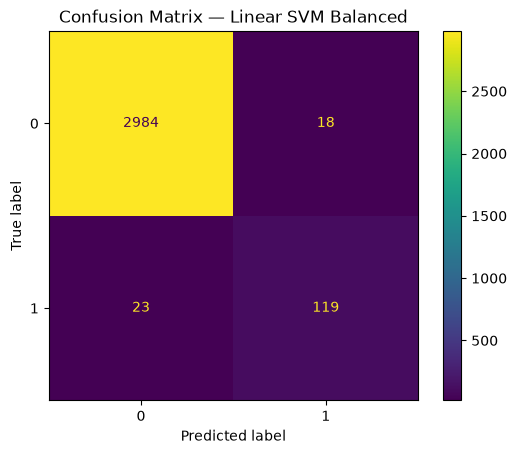

In [11]:
# Plot a confusion matrix for the best model from Experiment 1.
# If a balanced model wins, retrain it here before plotting.

if best_model_name in models:
    best_model = models[best_model_name]
else:
    best_model = balanced_models[best_model_name]

best_model.fit(X_train_tfidf, y_train)

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_tfidf,
    y_test,
)

plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()
